# What are Implicit Neural Representations?

INRs are learned mappings from a coordinate system to an arbitrary function.

An INR typically involves a multi-layer perceptron (MLP) being trained to take in a coordinate as input, and output the value of the function at that coordinate.

<center width="100%" style="padding:25px"><img src="https://www.researchgate.net/publication/346302971/figure/download/fig1/AS:961682037829650@1606294273728/An-illustration-of-an-image-represented-in-the-implicit-neural-representation-INR-form.png" width="400px"></center>

Once trained, we no longer need the explicit data it was trained on. The INR can be said to be __implicitly__ representing the function in the weights of the neural network, hence its name.

The type of functions we try to represent wildly vary depending on the application:
*   Image intensities (gray-scale, RGB, ...)
*   Shapes (occupancy values, signed distances, ...)
*   Vector fields (deformations, velocities, ...)




# Training a simple INR

In [1]:
import os, sys
from datetime import datetime

import torch
torch.cuda.is_available()

True

## Architecture

Implicit Neural Representations are typically defined as a series of dense layers with non-linear activation functions. The network is meant to learn a mapping between coordinates and the value of a function at those coordinates.


We will start by creating a network with ReLU layers. As we will see later, the naive use of Rectified Linear Units (ReLU) does not produce ideal results.

In [2]:
import torch
from torch import nn


class MLP(nn.Module):
    def __init__(self,
                 in_size: int,
                 out_size: int,
                 layer_class: nn.Module,
                 hidden_size: int = 128,
                 num_layers: int = 3,
                 **kwargs):
        super().__init__()

        a = [layer_class(in_size, hidden_size, is_first=True, **kwargs)]
        for i in range(num_layers - 1):
            a.append(layer_class(hidden_size, hidden_size, **kwargs))
        a.append(nn.Linear(hidden_size, out_size))
        self.layers = nn.ModuleList(a)

    def forward(self, x: torch.Tensor):
        for layer in self.layers:
            x = layer(x)
        return x

## Data

Unlike other areas of machine learning, we don't aim to generalize to unseen subjects. INRs are trained on exclusively one subject and aim to generalize onto unseen coordinates.

We will thus download only 1 image and aim to see how well the network is able to interpolate the image into arbitrary resolutions.


In [3]:
import cv2
from torchvision.transforms.functional import pil_to_tensor
import matplotlib.pyplot as plt


img = cv2.imread("/home/mpenkin/Pictures/lenna.png", -1)
img = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)[..., None]
print(img.shape, img.dtype, img.max(), img.min())

(512, 512, 1) uint8 245 25


Image shape: torch.Size([512, 512, 1])
Max: tensor(0.9608) Min: tensor(0.0980)


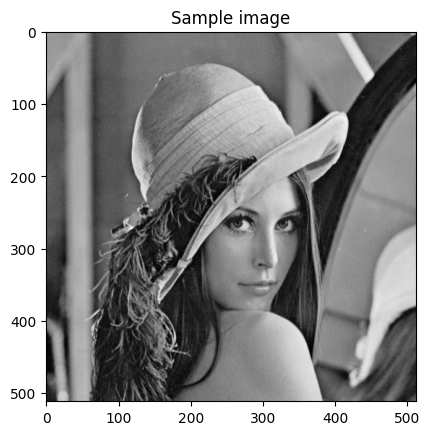

In [4]:
gt_image = torch.Tensor(img)
gt_image = gt_image.to(torch.float32) / 255.0
print("Image shape:", gt_image.shape)
print("Max:", gt_image.max(), "Min:", gt_image.min())
plt.imshow(gt_image, cmap='gray')
plt.title('Sample image')
plt.show()

Since the network takes in only one coordinate at a time, we want our dataloader to yield batches of coordinate-value pairs (as opposed to pairs of whole images and their coorresponding ground-truths like in other areas of supervised learning).

In [5]:
import torch
from torch.utils.data import Dataset, DataLoader
import random
import numpy as np


POINTS_PER_SAMPLE = 2048

class RandomPointsDataset(Dataset):
    def __init__(self, image: torch.Tensor, points_num: int = POINTS_PER_SAMPLE):
        super().__init__()
        self.device = "cpu"
        self.points_num = points_num
        assert image.dtype == torch.float32
        self.image = image.to(self.device)  # (H, W, ..., C)
        self.dim_sizes = self.image.shape[:-1]  # Size of each spatial dimension

        # To help us define the input/output sizes of our network later
        # we store the size of our input coordinates and output values
        self.coord_size = len(self.image.shape[:-1])  # Number of spatial dimensions
        self.value_size = self.image.shape[-1]  # Channel size

    def __len__(self):
        return 1

    def __getitem__(self, idx: int):
        # Create random sample of pixel indices
        point_indices = [torch.randint(0, i, (self.points_num,), device=self.device) for i in self.dim_sizes]

        # Retrieve image values from selected indices
        point_values = self.image[tuple(point_indices)]

        # Convert point indices into normalized [-1.0, 1.0] coordinates
        point_coords = torch.stack(point_indices, dim=-1)
        spatial_dims = torch.tensor(self.dim_sizes, device=self.device)
        point_coords_norm = point_coords / spatial_dims * 2.0 - 1.0

        # The subject index is also returned in case the user wants to use subject-wise learned latents
        return point_coords_norm, point_values

dataset = RandomPointsDataset(gt_image, points_num=POINTS_PER_SAMPLE)
# We set a batch_size of 1 since our dataloader is already returning a batch of points.
dataloader = DataLoader(dataset, batch_size=1, num_workers=0, pin_memory=True)

In [6]:
coords, values = next(iter(dataloader))
print(coords.shape, values.shape)

torch.Size([1, 2048, 2]) torch.Size([1, 2048, 1])


## Experiments

Use Pytorch Lightning!

In [7]:
from typing import Tuple, List, Optional
import numpy as np
import torch
import matplotlib.pyplot as plt


def plot_reconstructions(progress_ims: List[Tuple[int, torch.Tensor]], gt_im: torch.Tensor):
    ncols = len(progress_ims) + 1
    fig_width = 5
    fig, axs = plt.subplots(ncols=ncols, figsize=(ncols*fig_width, fig_width))
    for i, (epoch, im, metric) in enumerate(progress_ims):
        im = im.cpu().numpy()
        ax = axs[i]
        ax.imshow(im, cmap='gray')
        ax.axis('off')
        title = f'Epoch: {epoch}, PSNR: {metric}'
        ax.set_title(title)
    gt_im = gt_im.cpu().numpy()
    axs[-1].imshow(gt_im, cmap='gray')
    axs[-1].axis('off')
    axs[-1].set_title('Ground Truth')
    plt.tight_layout()
    plt.show()

def psnr(pred, ref):
    max_value = ref.max()
    mse = torch.mean((pred - ref) ** 2, dim=(-2, -1))
    out = 20 * torch.log10(max_value / torch.sqrt(mse))
    return out.mean()

def plot_scores(models: List['INRModule']):
    fig, ax = plt.subplots()
    for model in models:
        epochs, scores = [i for i, _ in model.scores], [v for _, v in model.scores]
        ax.plot(epochs, scores, label=model.name)
    ax.set_xlabel('Epoch')
    ax.set_ylabel('PSNR')
    ax.set_title('PSNR over epochs')
    ax.legend()
    plt.show()

In [8]:
from torch import nn
import lightning as pl


class INRLightningModule(pl.LightningModule):
    def __init__(self,
                 network: MLP,
                 gt_im: torch.Tensor,
                 lr: float = 0.001,
                 name: str = "",
                 eval_interval: int = 100,
                 visualization_intervals: List[int] = [0, 100, 500, 1000, 5000, 10000],
                ):
        super().__init__()
        self.lr = lr
        self.network = network

        # Logging
        self.name = name
        self.gt_im = gt_im
        self.eval_interval = eval_interval
        self.visualization_intervals = visualization_intervals
        self.progress_ims = []
        self.scores = []

    def configure_optimizers(self):
        return torch.optim.Adam(self.network.parameters(), lr=self.lr)

    def forward(self, coords):
        return self.network(coords)

    def training_step(self, batch, batch_idx):
        coords, values = batch
        coords = coords.view(-1, coords.shape[-1])
        values = values.view(-1, values.shape[-1])
        outputs = self.forward(coords)
        loss = nn.functional.mse_loss(outputs, values)
        return loss

    def on_train_epoch_end(self):
        """ At each visualization interval, reconstruct the image using our INR """
        if (self.current_epoch + 1) % self.eval_interval == 0 or self.current_epoch == 0:
            pred_im = self.sample_at_resolution(self.gt_im.shape[:-1])
            pred_im = pred_im.reshape(self.gt_im.shape)
            psnr_value = psnr(pred_im, self.gt_im.to(pred_im.device)).cpu().item()
            self.scores.append((self.current_epoch + 1, psnr_value))  # Log PSNR
            if self.current_epoch + 1 in self.visualization_intervals:
                self.progress_ims.append((self.current_epoch + 1, pred_im.cpu(), psnr_value))

    @torch.no_grad()
    def sample_at_resolution(self, resolution: Tuple[int, ...]):
        """ Evaluate our INR on a grid of coordinates in order to obtain an image. """
        meshgrid = torch.meshgrid([torch.arange(0, i, device=self.device) for i in resolution], indexing='ij')
        coords = torch.stack(meshgrid, dim=-1)
        coords_norm = coords / torch.tensor(resolution, device=self.device) * 2.0 - 1.0
        coords_norm_ = coords_norm.reshape(-1, coords.shape[-1])
        predictions_ = self.forward(coords_norm_)
        predictions = predictions_.reshape(resolution)
        return predictions

## 1. ReLU + MLP

In [9]:
class ReLULayer(nn.Module):
    def __init__(self,
                 in_size: int,
                 out_size: int,
                 **kwargs):
        super().__init__()
        self.linear = nn.Linear(in_size, out_size, bias=True)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        x = self.linear(x)
        x = torch.relu(x)
        return x

In [10]:
HIDDEN_SIZE = 128
NUM_LAYERS = 3

LEARNING_RATE = 1e-3
TRAINING_EPOCHS = 5000

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
You are using a CUDA device ('NVIDIA GeForce RTX 4080 Laptop GPU') that has Tensor Cores. To properly utilize them, you should set `torch.set_float32_matmul_precision('medium' | 'high')` which will trade-off precision for performance. For more details, read https://pytorch.org/docs/stable/generated/torch.set_float32_matmul_precision.html#torch.set_float32_matmul_precision
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

  | Name    | Type | Params | Mode 
-----------------------------------------
0 | network | MLP  | 33.5 K | train
-----------------------------------------
33.5 K    Trainable params
0         Non-trainable params
33.5 K    Total params
0.134     Total estimated model params size (MB)
9         Modules in train mode
0         Modules in eval mode
/home/mpenkin/venv_research/lib/python3.12/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:425: 

Epoch 4999: 100%|██████████████████████| 1/1 [00:00<00:00, 287.42it/s, v_num=16]

`Trainer.fit` stopped: `max_epochs=5000` reached.


Epoch 4999: 100%|███████████████████████| 1/1 [00:00<00:00, 84.26it/s, v_num=16]
Fitting time: 0:00:28.591846s.


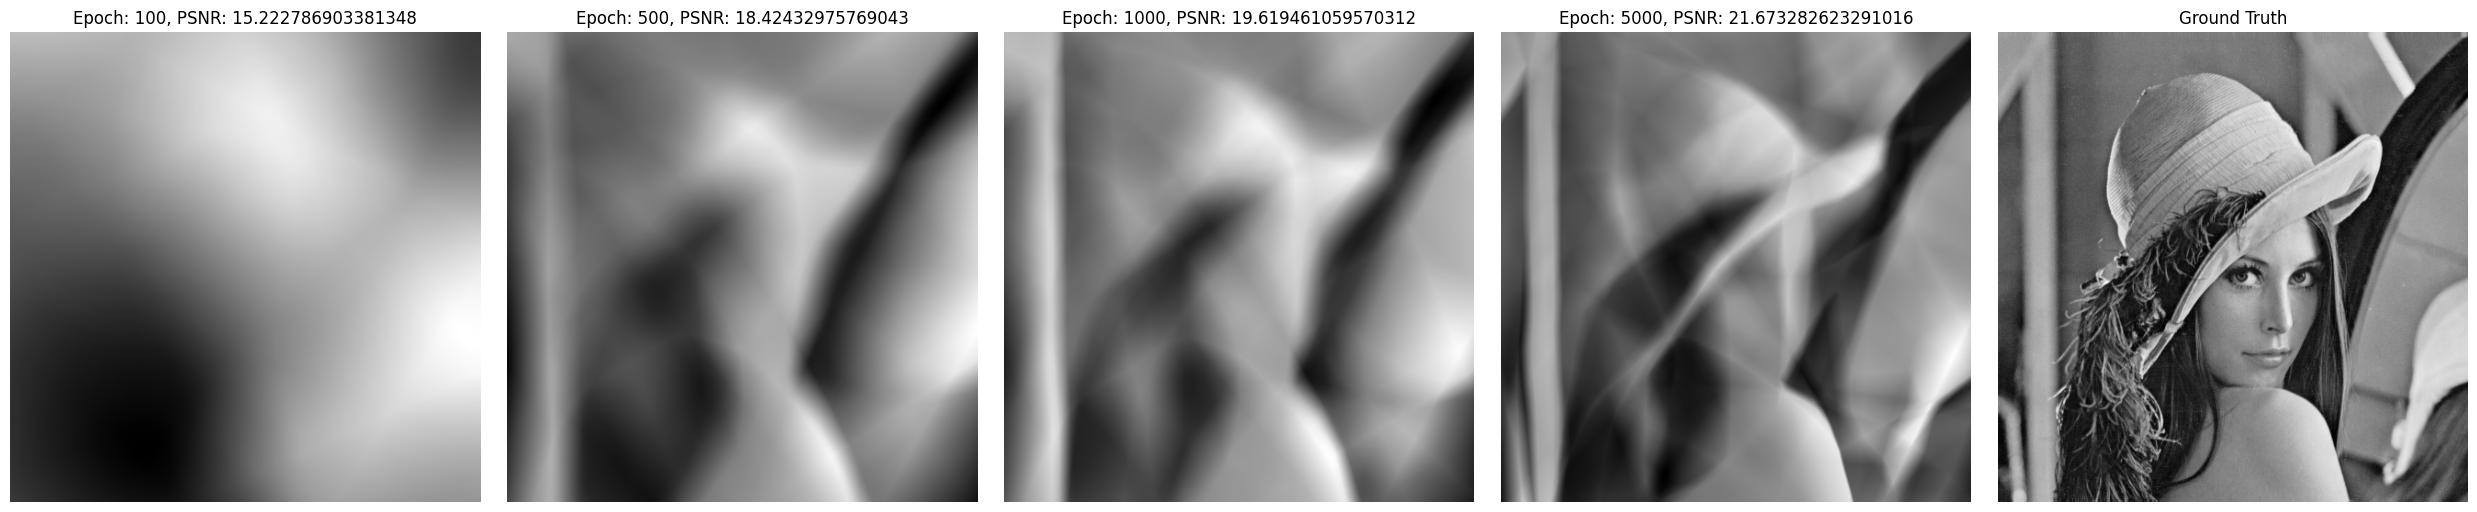

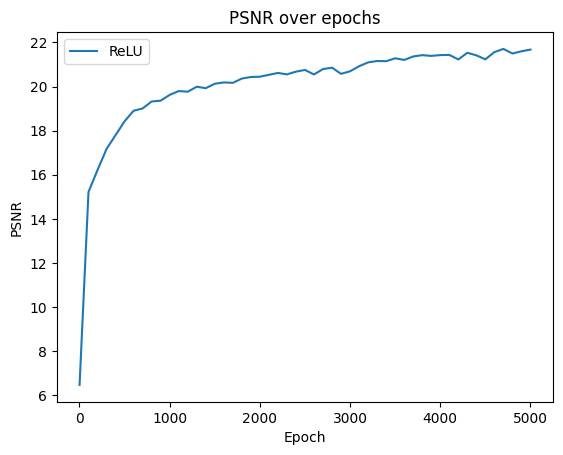

In [11]:
inr = MLP(dataset.coord_size,
          dataset.value_size,
          hidden_size=HIDDEN_SIZE,
          num_layers=NUM_LAYERS,
          layer_class=ReLULayer,
         )

##############################################################################################

inr_module = INRLightningModule(network=inr, 
                                lr=LEARNING_RATE,
                                gt_im=gt_image,
                                name='ReLU',
                                eval_interval=100,
                                visualization_intervals=[0, 100, 500, 1000, 5000, 10000],
                                )
trainer = pl.Trainer(max_epochs=TRAINING_EPOCHS)
s = datetime.now()
trainer.fit(inr_module, train_dataloaders=dataloader)
print(f"Fitting time: {datetime.now()-s}s.")

##############################################################################################

plot_reconstructions(inr_module.progress_ims, gt_image)
plot_scores([inr_module])

Standard MLPs are known to fail to model the high frequency components of signals. This *spectral bias* causes INRs to produce blurry reconstructions such as the ones from our trained model above.

Let's see what can be done to improve reconstruction fidelity.


## 2. SIREN + MLP

One such INR variant are sinusoidal representation networks (SIREN) as proposed by the paper [*Implicit Neural Representations with Periodic Activation Functions*](https://www.vincentsitzmann.com/siren/).

One important parameter to take into account is the *siren factor* $\omega_0$ which is used to scale the frequency of our layer activations. We can use this parameter to make the network better learn high spatial frequency components. A higher value of $\omega_0$ will allow the network to capture high-frequency components, but it will also introduce noisy artifacts into our reconstruction. The authors empirically propose a value of $\omega_0 = 30.0$.

In [12]:
class SineLayer(nn.Module):    
    # If is_first=True, omega_0 is a frequency factor which simply multiplies the activations before the 
    # nonlinearity. Different signals may require different omega_0 in the first layer - this is a 
    # hyperparameter.
    
    # If is_first=False, then the weights will be divided by omega_0 so as to keep the magnitude of 
    # activations constant, but boost gradients to the weight matrix (see supplement Sec. 1.5)
    
    def __init__(self, in_features, out_features, bias=True,
                 is_first=False, omega_0=30):
        super().__init__()
        self.omega_0 = omega_0
        self.is_first = is_first
        
        self.in_features = in_features
        self.linear = nn.Linear(in_features, out_features, bias=bias)
        
        self.init_weights()
    
    def init_weights(self):
        with torch.no_grad():
            if self.is_first:
                self.linear.weight.uniform_(-1 / self.in_features, 
                                             1 / self.in_features)      
            else:
                self.linear.weight.uniform_(-np.sqrt(6 / self.in_features) / self.omega_0, 
                                             np.sqrt(6 / self.in_features) / self.omega_0)
        
    def forward(self, input):
        return torch.sin(self.omega_0 * self.linear(input))

In [13]:
SIREN_FACTOR=30

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

  | Name    | Type | Params | Mode 
-----------------------------------------
0 | network | MLP  | 33.5 K | train
-----------------------------------------
33.5 K    Trainable params
0         Non-trainable params
33.5 K    Total params
0.134     Total estimated model params size (MB)
9         Modules in train mode
0         Modules in eval mode


Epoch 4999: 100%|██████████████████████| 1/1 [00:00<00:00, 319.18it/s, v_num=17]

`Trainer.fit` stopped: `max_epochs=5000` reached.


Epoch 4999: 100%|███████████████████████| 1/1 [00:00<00:00, 76.62it/s, v_num=17]
Fitting time: 0:00:28.963694s.


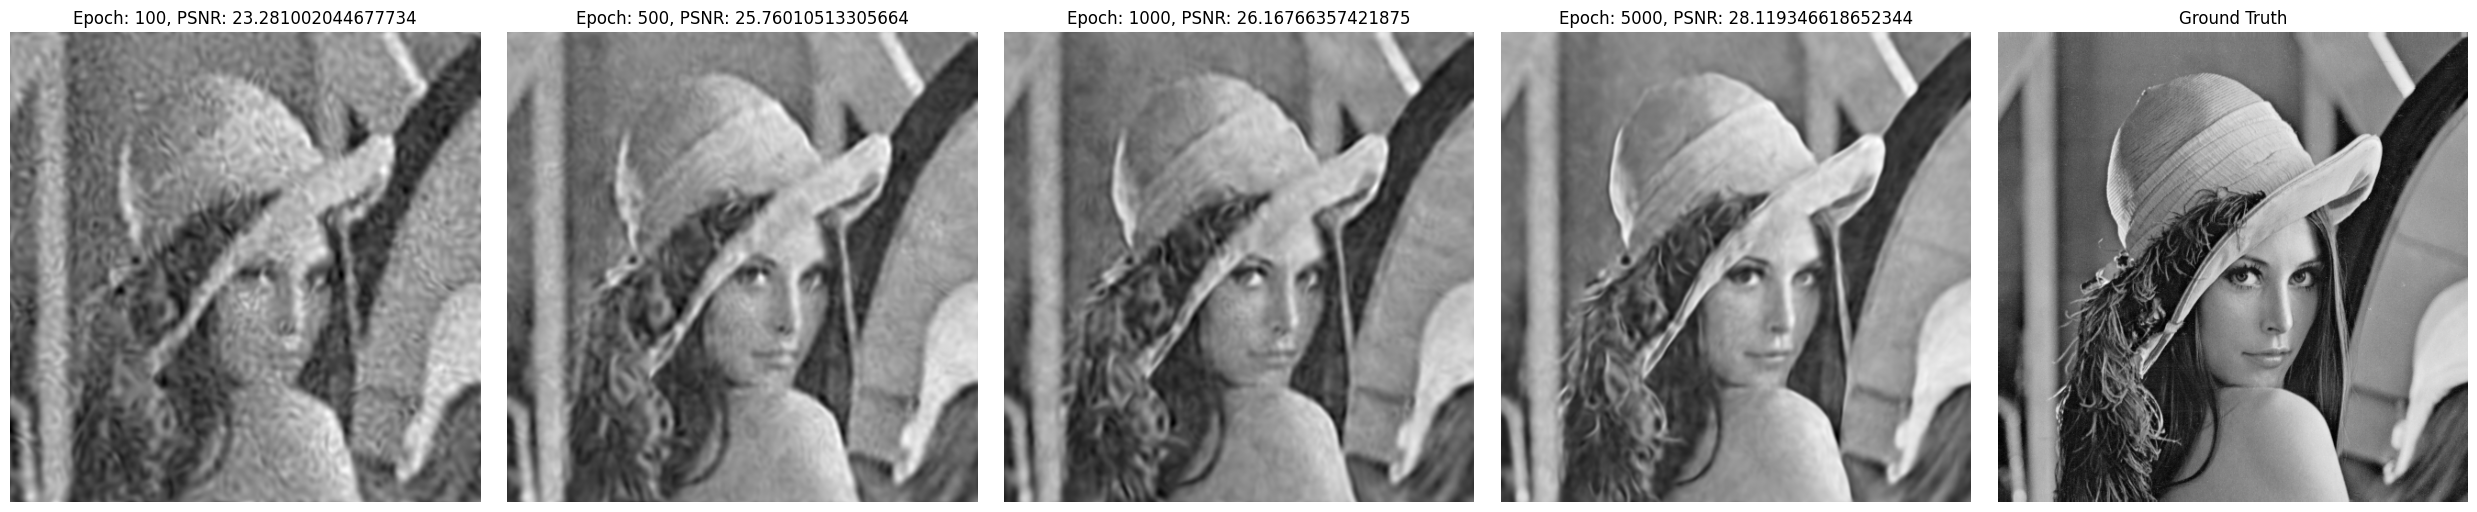

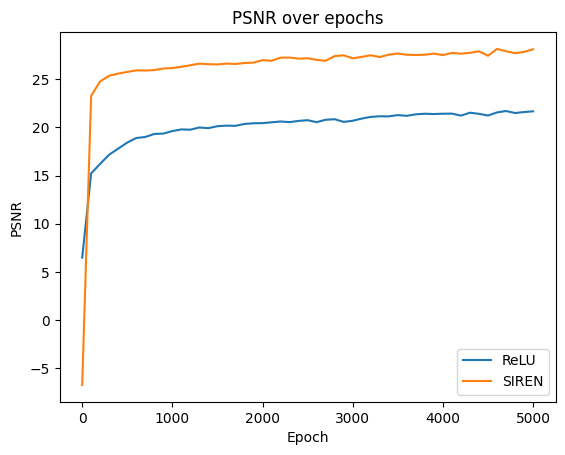

In [14]:
siren_inr = MLP(dataset.coord_size,
                dataset.value_size,
                hidden_size=HIDDEN_SIZE,
                num_layers=NUM_LAYERS,
                layer_class=SineLayer, 
                omega_0=SIREN_FACTOR,
                )

##############################################################################################

siren_module = INRLightningModule(network=siren_inr,
                                  gt_im=gt_image,
                                  lr=LEARNING_RATE,
                                  name='SIREN',
                                 )
trainer = pl.Trainer(max_epochs=TRAINING_EPOCHS)
s = datetime.now()
trainer.fit(siren_module, train_dataloaders=dataloader)
print(f"Fitting time: {datetime.now()-s}s.")

##############################################################################################

plot_reconstructions(siren_module.progress_ims, gt_image.cpu())
plot_scores([inr_module,
             siren_module])